In [1]:
import os
import pypsa
import pycountry
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

from unit_helpers import (
    tj_to_twh,
    bcm_to_twh,
)

from data_preparing import (
    plot_total_gas_supply,
    add_shared_row_title,
    basic_axis_formatting,
    plot_stacked_bars,
    get_model_pipeline_imports,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    industry_demands,
    rescom_demands,
    plot_country_consumption,
)

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [2]:
path = Path.cwd().parent / 'resources'
regions = gpd.read_file(path / 'regions_onshore_base_s_50.geojson')
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401
INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [3]:
from gas_validation_data import (
    df_2024_residential,
    df_2024_industrial,
    df_2024_production,
    df_pipeline_imports,
    df_total_supply,
    df_storage_2024,
)

df_2024_residential = bcm_to_twh(df_2024_residential)
df_2024_industrial = bcm_to_twh(df_2024_industrial)
df_2024_production = bcm_to_twh(df_2024_production)
df_pipeline_imports = bcm_to_twh(df_pipeline_imports)
df_total_supply = bcm_to_twh(df_total_supply)
df_storage_2024 = bcm_to_twh(df_storage_2024)

ccon = pd.read_csv(
    'nrg_cb_gas$defaultview_linear_2_0.csv'
)
ccon = (
    ccon.loc[ccon['TIME_PERIOD'] == 2024]
    .set_index('Geopolitical entity (reporting)')
    ['OBS_VALUE']
    .rename('gas_demand')
    .apply(tj_to_twh)
)

def country_name_to_iso2(name):
    name = name.strip()
    try:
        return pycountry.countries.lookup(name).alpha_2
    except LookupError:
        return None

ccon = ccon.copy()
ccon.index = ccon.index.map(country_name_to_iso2)
ccon = ccon[~ccon.index.isnull()]
ccon = ccon.sort_values(ascending=False)

In [4]:
gens = n.generators.index[n.generators.carrier == 'gas']

In [5]:
n.statistics

yet to implement other pipeline representation in model!


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

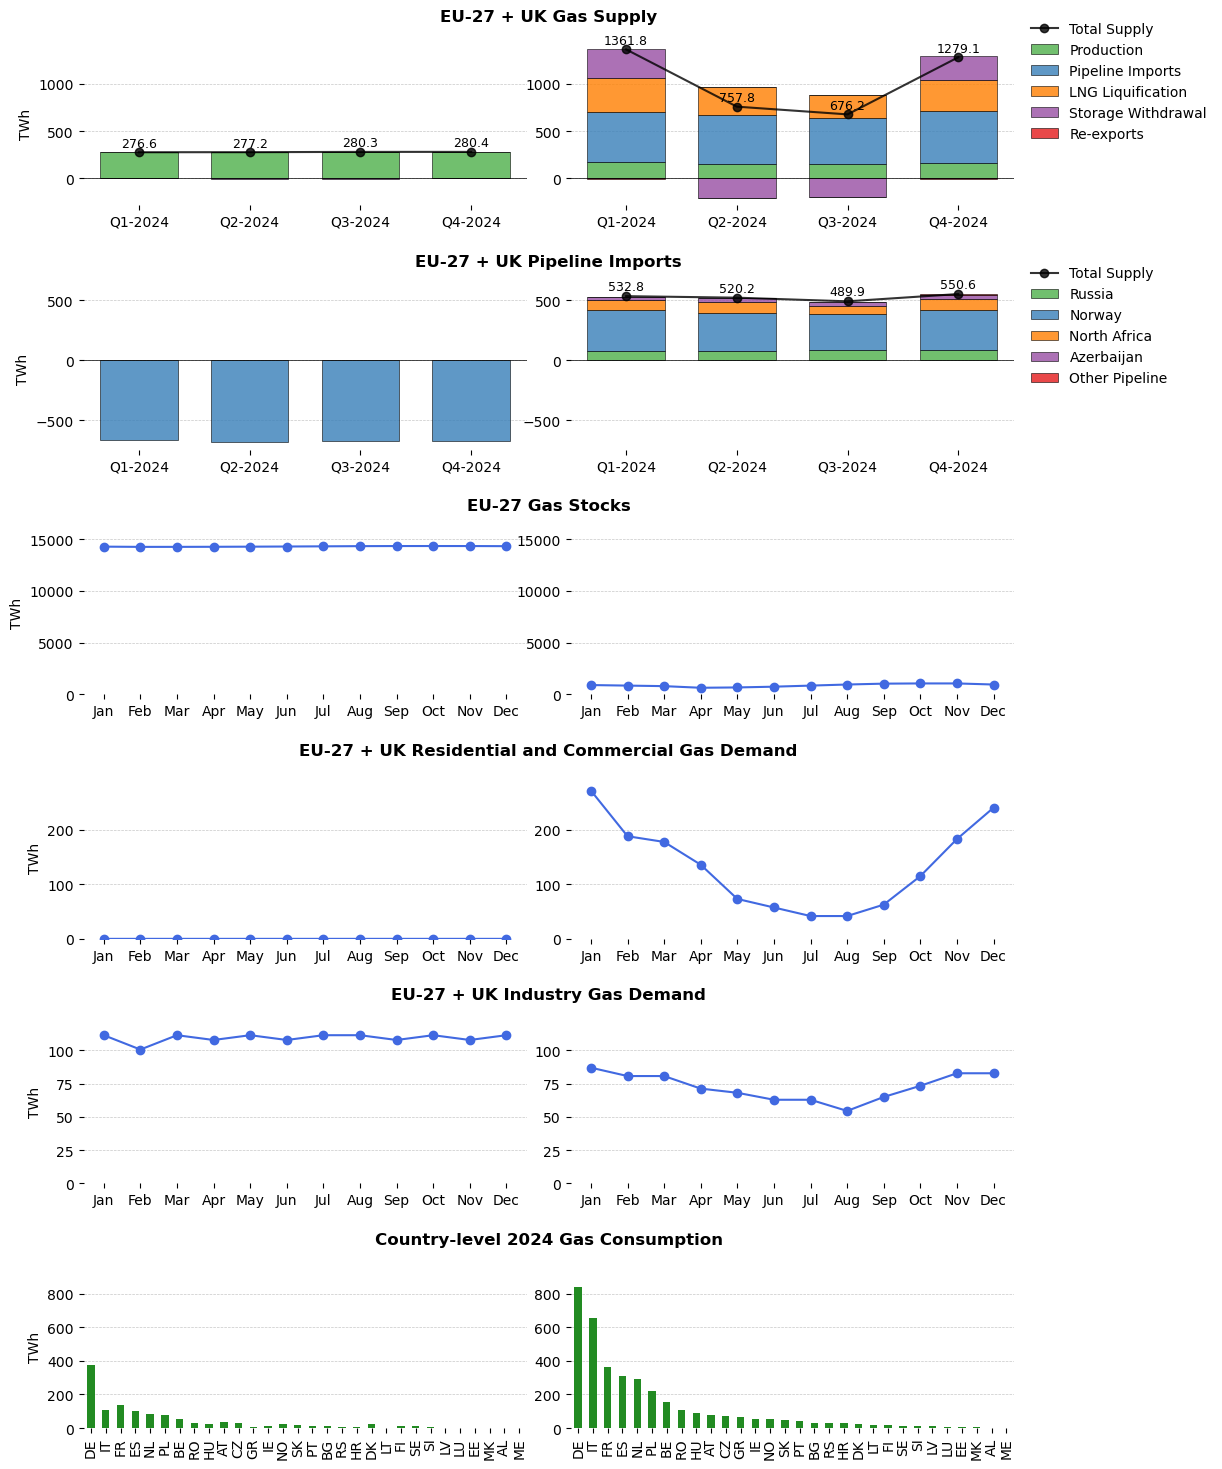

In [6]:

fig_height = 3 * 6  # 3 inches per row
fig_width = 12      # 2*2*3 = 12 inches for 2:1 aspect per ax, 2 axes per row
fig, axes = plt.subplots(
    nrows=6,
    ncols=2,
    figsize=(fig_width, fig_height),
    gridspec_kw={'wspace':0.1, 'hspace':0.5}
    )

row_fns = [
    plot_total_gas_supply,
    plot_pipeline_imports,
    plot_eu_gas_stock,
    plot_residential_commercial_demand,
    plot_industry_demand,
    plot_country_consumption,
]

right_data_list = [
    df_total_supply,
    df_pipeline_imports,
    df_storage_2024,
    df_2024_residential,
    df_2024_industrial,
    ccon,
]

for i in range(6):
    model_ax = axes[i, 0]
    true_ax = axes[i, 1]
    row_fns[i](model_ax, true_ax, n, right_data_list[i], fig, i)

    model_ax.set_xlabel("")
    model_ax.set_ylabel("")
    true_ax.set_xlabel("")
    true_ax.set_ylabel("")

    fig.canvas.draw()  # Needed to ensure positions are up to date
    bbox1 = model_ax.get_position()
    bbox2 = true_ax.get_position()

    x0 = bbox1.x1 - 0.02 * (bbox2.x0 - bbox1.x1)  # slight overlap
    width = bbox2.x0 - bbox1.x1 + 0.04 * (bbox2.x0 - bbox1.x1)
    y0 = bbox1.y0
    height = bbox1.height

    bbox_top = model_ax.get_position()
    bbox_bottom = model_ax.get_position()
    y0 = bbox_bottom.y0
    height = (bbox_top.y1 - bbox_bottom.y0) / 5

    '''
    rect = patches.FancyBboxPatch(
        (x0, y0), width, height,
        boxstyle="round,pad=0.02",
        linewidth=1, edgecolor='gray', facecolor='white', alpha=0.95,
        transform=fig.transFigure, zorder=10
    )

    fig.patches.append(rect)

    fig.text(
        x0 + width/2, y0 + height/2,
        f"Legend/Explanation\nPlaceholder\n(Row {i+1})",
        ha='center', va='center', fontsize=10, color='black', zorder=11
    )
    '''

for ax in axes[:,0]:
    ax.set_ylabel('TWh')

plt.savefig('validation_starting_point.pdf', bbox_inches='tight')
plt.show()

In [10]:
ss = n.statistics.energy_balance(groupby=['carrier', 'bus'])

ss.loc[
    (ss.index.get_level_values(2).str.contains('gas')) &
    (ss.index.get_level_values(2).str.contains('NO')) &
    (ss.index.get_level_values(1) == 'gas pipeline')
]

component  carrier       bus      
Link       gas pipeline  NO1 0 gas    2687.44371
dtype: float64

In [19]:
pipes = n.links.index[n.links.carrier == 'gas pipeline']

bus
LT0 0 gas    3.596098e+06
GR0 0 gas    6.689875e+06
FI1 0 gas    8.075252e+06
SE1 0 gas    8.463672e+06
IE3 0 gas    1.060085e+07
BG0 0 gas    1.201932e+07
PT0 0 gas    1.307775e+07
AT0 0 gas    1.564356e+07
DK0 0 gas    1.659593e+07
GB2 0 gas    2.138196e+07
NO1 0 gas    2.504610e+07
RO0 0 gas    2.934733e+07
SK0 0 gas    2.989146e+07
DE0 0 gas    3.042691e+07
FR0 1 gas    3.071230e+07
IT0 0 gas    3.210009e+07
FR0 3 gas    3.506469e+07
GB2 1 gas    3.549368e+07
DE0 5 gas    4.537190e+07
HU0 0 gas    4.715616e+07
IT0 1 gas    5.190089e+07
BE0 0 gas    5.330786e+07
FR0 0 gas    6.565042e+07
NL0 0 gas    8.022152e+07
PL0 0 gas    9.143586e+07
ES0 0 gas    1.014212e+08
DE0 2 gas    2.137911e+08
dtype: float64

In [20]:
n.buses.carrier.unique()

array(['AC', 'lignite', 'coal', 'oil', 'oil primary', 'uranium', 'none',
       'co2', 'co2 stored', 'co2 sequestered', 'gas', 'H2', 'battery',
       'EV battery', 'land transport oil', 'urban central heat',
       'urban central water tanks', 'urban central water pits', 'biogas',
       'solid biomass', 'unsustainable bioliquids', 'NH3', 'methanol',
       'solid biomass for industry', 'gas for industry',
       'industry methanol', 'naphtha for industry', 'non-sequestered HVC',
       'process emissions', 'coal for industry', 'shipping oil',
       'kerosene for aviation', 'agriculture machinery oil',
       'low voltage', 'home battery', 'rural heat', 'rural water tanks',
       'urban decentral heat', 'urban decentral water tanks'],
      dtype=object)

In [23]:
idx = pd.IndexSlice
n.statistics.energy_balance(groupby=['carrier']).loc[idx['Load', :]].sort_values()

carrier
residential urban decentral heat    -1.217715e+09
gas for industry                    -1.175320e+09
industry electricity                -1.070670e+09
naphtha for industry                -8.961300e+08
kerosene for aviation               -7.439070e+08
shipping oil                        -5.784152e+08
land transport oil                  -5.085732e+08
coal for industry                   -4.987831e+08
residential rural heat              -4.291998e+08
solid biomass for industry          -3.672000e+08
urban central heat                  -2.873205e+08
agriculture heat                    -2.148117e+08
low-temperature heat for industry   -1.856000e+08
NH3                                 -8.730000e+07
agriculture machinery oil           -5.142382e+07
agriculture electricity             -3.752588e+07
agriculture machinery electric      -2.203878e+07
land transport EV                   -1.116298e+07
industry methanol                   -8.740000e+06
H2 for industry                      8.790

In [93]:
eb = n.statistics.energy_balance(groupby=['carrier', 'bus'])
eb = eb.loc[eb.index.get_level_values(2).str.contains('urban decentral heat')]
eb = eb.groupby(level=[0,1]).sum()

In [94]:
eb.sort_values()

component  carrier                                           
Generator  services urban decentral heat vent                   -1.804269e+09
Load       residential urban decentral heat                     -1.217715e+09
Link       residential urban decentral water tanks charger      -3.879796e+04
Load       low-temperature heat for industry                    -2.000000e+04
Link       DAC                                                  -7.488239e+01
           services urban decentral biomass boiler               9.792976e+01
           urban decentral oil boiler                            9.850123e+01
           residential urban decentral water tanks discharger    3.871713e+04
           residential urban decentral gas boiler                1.244133e+06
           services urban decentral air heat pump                9.332275e+07
           services urban decentral resistive heater             2.927437e+09
dtype: float64

In [95]:
oc = n.statistics.optimal_capacity(groupby=['carrier', 'bus'])
oc = oc.loc[oc.index.get_level_values(2).str.contains('urban decentral heat')]
oc = oc.groupby(level=[0,1]).sum()
oc.sort_values()

component  carrier                                        
Link       residential urban decentral water tanks charger         8.78690
Generator  services urban decentral heat vent                 385044.99234
dtype: float64

In [96]:
ic = n.statistics.optimal_capacity(groupby=['carrier', 'bus'])
ic = ic.loc[ic.index.get_level_values(2).str.contains('urban decentral heat')]
ic = ic.groupby(level=[0,1]).sum()
ic.sort_values()

component  carrier                                        
Link       residential urban decentral water tanks charger         8.78690
Generator  services urban decentral heat vent                 385044.99234
dtype: float64

In [97]:
n.links.loc[n.links.carrier == 'services urban decentral resistive heater']

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,tags,underwater_fraction,energy to power ratio,voltage,project_status,under_construction,reversed,location,dc,underground
Link,,,,,,,,,,,,,,,,,,,,,


In [98]:
heat_demands = pd.Index(n.statistics.energy_balance().index.get_level_values(2).unique())
heat_demands = heat_demands[heat_demands.str.contains('heat')]
heat_demands

Index(['residential rural heat', 'residential urban decentral heat',
       'urban central heat'],
      dtype='object', name='bus_carrier')

In [99]:
eb = n.statistics.energy_balance()
eb

component  carrier                               bus_carrier                     
Store      Battery Storage                       Battery Storage                     1.010000e-03
           EV battery                            EV battery                          1.729000e-02
           co2                                   co2                                -1.195319e+09
           home battery                          home battery                        1.170000e-03
           non-sequestered HVC                   non-sequestered HVC                 8.071763e+08
                                                                                         ...     
Link       urban central water tanks discharger  urban central heat                  1.101287e+04
                                                 urban central water tanks          -1.101287e+04
           urban decentral oil boiler            co2                                 4.019019e+01
                                    

In [100]:
heat_demands

Index(['residential rural heat', 'residential urban decentral heat',
       'urban central heat'],
      dtype='object', name='bus_carrier')

residential rural heat
===============-----------------------------
residential rural heat
Index(['agriculture heat', 'residential rural gas boiler',
       'residential rural ground heat pump', 'residential rural heat',
       'rural oil boiler', 'services rural air heat pump',
       'services rural biomass boiler', 'services rural heat vent',
       'services rural resistive heater', 'services rural water tanks charger',
       'services rural water tanks discharger'],
      dtype='object', name='carrier')
residential urban decentral heat
===============-----------------------------
residential urban decentral heat
Index(['DAC', 'low-temperature heat for industry',
       'residential urban decentral gas boiler',
       'residential urban decentral heat',
       'residential urban decentral water tanks charger',
       'residential urban decentral water tanks discharger',
       'services urban decentral air heat pump',
       'services urban decentral biomass boiler',
       'servi

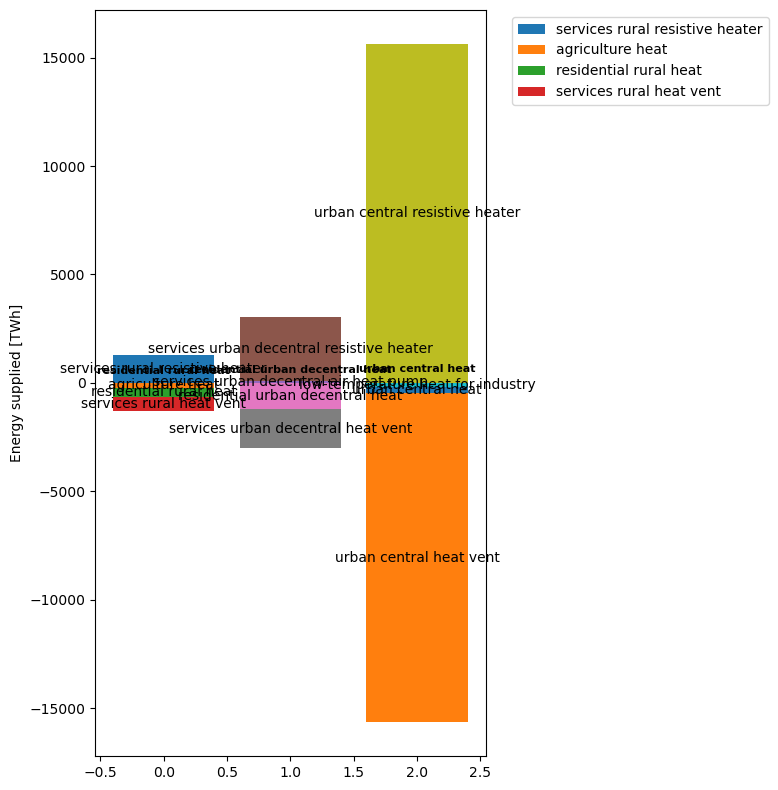

In [104]:
idx = pd.IndexSlice
fig, ax = plt.subplots(figsize=(8, 8))

for i, heat_demand in enumerate(heat_demands):

    print(heat_demand)

    try:
        ss = eb.loc[idx[: ,: ,heat_demand]]
    except KeyError:
        continue

    total = ss.clip(lower=0).sum()
    ss = ss.groupby(level=1).sum()
    print('===============-----------------------------')
    print(heat_demand)
    print(ss.index)
    ss = ss.loc[ss.abs() > 0.01 * total].mul(1e-6)

    # Split into positive and negative parts
    ss_pos = ss[ss > 0]
    ss_neg = ss[ss < 0]

    # Plot positive stack
    bottoms_pos = 0
    for j, (idx_val, val) in enumerate(ss_pos.items()):
        bar = ax.bar(
            i, val, bottom=bottoms_pos, label=idx_val if i == 0 else "", width=0.8, color=None
        )
        ax.text(
            i, bottoms_pos + val / 2,
            str(idx_val),
            ha='center', va='center', fontsize=10, color='k'
        )
        bottoms_pos += val

    # Plot negative stack
    bottoms_neg = 0
    for j, (idx_val, val) in enumerate(ss_neg.items()):
        bar = ax.bar(
            i, val, bottom=bottoms_neg, label=idx_val if i == 0 else "", width=0.8, color=None
        )
        ax.text(
            i, bottoms_neg + val / 2,
            str(idx_val),
            ha='center', va='center', fontsize=10, color='k'
        )
        bottoms_neg += val

    # Optionally, add text above the stack stating heat_demand
    ax.text(
        i, 300 + i * 50,
        heat_demand,
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

ax.set_ylabel('Energy supplied [TWh]')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [91]:
# Find all links where any of bus0, bus1, bus2, or bus3 has a carrier in heat_demands
mask = (
    n.links['bus0'].map(lambda b: n.buses.loc[b, 'carrier'] if b in n.buses.index else None).isin(heat_demands) |
    n.links['bus1'].map(lambda b: n.buses.loc[b, 'carrier'] if b in n.buses.index else None).isin(heat_demands) |
    n.links['bus2'].map(lambda b: n.buses.loc[b, 'carrier'] if b in n.buses.index else None).isin(heat_demands) |
    n.links['bus3'].map(lambda b: n.buses.loc[b, 'carrier'] if b in n.buses.index else None).isin(heat_demands)
)
# Find, for each link carrier, the set of heat demand bus carriers it is actually connected to (across bus0-3)
from collections import defaultdict

carrier_to_heat_demand = defaultdict(set)

for idx, row in n.links.iterrows():
    for bus_col in ['bus0', 'bus1', 'bus2', 'bus3']:
        bus = row.get(bus_col, None)
        if pd.isna(bus) or bus not in n.buses.index:
            continue
        bus_carrier = n.buses.at[bus, 'carrier']
        if bus_carrier in heat_demands:
            carrier_to_heat_demand[row['carrier']].add(bus_carrier)

# Convert sets to sorted lists for presentation
carrier_to_heat_demand = {carrier: sorted(list(heat_set)) for carrier, heat_set in carrier_to_heat_demand.items() if heat_set}

carrier_to_heat_demand

{'H2 Electrolysis': ['urban central heat'],
 'H2 Fuel Cell': ['urban central heat'],
 'Sabatier': ['urban central heat'],
 'urban central water tanks charger': ['urban central heat'],
 'urban central water tanks discharger': ['urban central heat'],
 'urban central water pits charger': ['urban central heat'],
 'urban central water pits discharger': ['urban central heat'],
 'urban central air heat pump': ['urban central heat'],
 'urban central resistive heater': ['urban central heat'],
 'urban central gas boiler': ['urban central heat'],
 'urban central gas CHP': ['urban central heat'],
 'urban central gas CHP CC': ['urban central heat'],
 'urban central solid biomass CHP': ['urban central heat'],
 'urban central solid biomass CHP CC': ['urban central heat'],
 'Haber-Bosch': ['urban central heat'],
 'Fischer-Tropsch': ['urban central heat'],
 'DAC': ['urban central heat']}